In [1]:
import numpy as np
import pandas as pd 
import scipy.stats
import gudhi as gd
import networkx as nx 
import random
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [16]:
df

,Unnamed: 0.1,Unnamed: 0,0,1,2,3,4,5,6,7,...,397,398,399,400,401,402,betha,seed,EPH,corr
0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.1,0,1.000000,0.000000
1,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.1,1,1.000000,0.000000
2,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.1,2,1.000000,0.000000
3,3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.1,3,1.000000,0.000000
4,4,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.1,4,1.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,1195,1195,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.4,295,2.693370,0.128864
1196,1196,1196,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.4,296,1.000000,0.000000
1197,1197,1197,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.4,297,3.082245,0.518447
1198,1198,1198,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.4,298,1.000000,0.000000


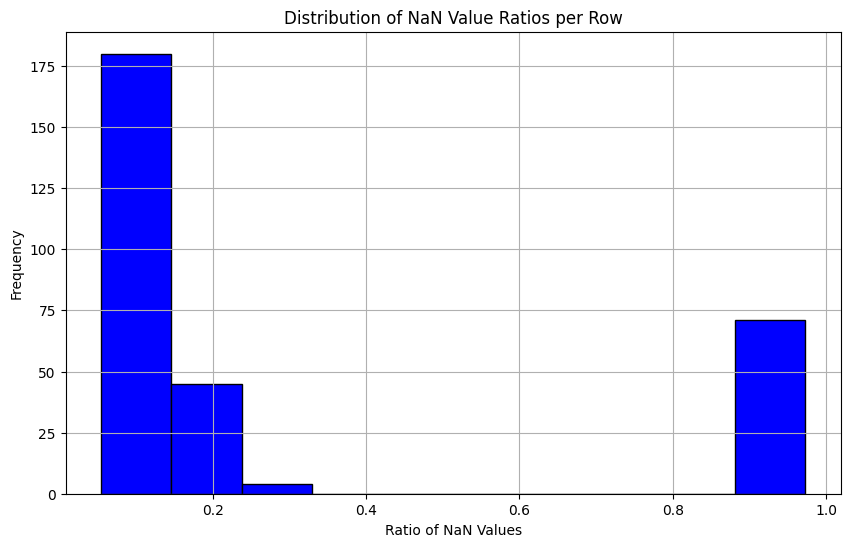

In [8]:
df = pd.read_csv('../results/weighted/given_betha_n=300/weighted_simple_conf.csv')
nan_ratio_per_row = df[df['betha'] == 0.8].drop(['Unnamed: 0'],axis=1).isna().mean(axis=1)

# Plot distribution of NaN values
plt.figure(figsize=(10, 6))
plt.hist(nan_ratio_per_row, bins=10, edgecolor='black', color='blue')
plt.title('Distribution of NaN Value Ratios per Row')
plt.xlabel('Ratio of NaN Values')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [26]:
import networkx as nx
network_name = "email_eu"
# Load the graph from a file (adjust the file type and path)
graph = nx.read_graphml(f'../networks/weighted/G_weighted_{network_name}_original.graphml')  # Example: change to .gml, .edgelist, etc., as needed
print('init number of nodes = ', len(graph.nodes))
# Find and remove nodes with only self-loops
nodes_to_remove = [] 
for i in range(len(nx.to_numpy_array(graph))):
    if nx.to_numpy_array(graph)[i][i] == 1 and np.sum(nx.to_numpy_array(graph)[i]) == 1:
        nodes_to_remove.append(list(graph.nodes)[i])

# # Remove the nodes from the graph
graph.remove_nodes_from(nodes_to_remove)

# Save the modified graph back to a file (adjust the file type and path)
nx.write_graphml(graph, f'../networks/weighted/G_weighted_{network_name}_modified.graphml')  # Example: change to .gml, .edgelist, etc., as needed
print('final number of nodes = ', len(graph.nodes))


init number of nodes =  1005
final number of nodes =  986


In [27]:
import networkx as nx
network_name = "email_eu"
# Load the graph from a file (adjust the file type and path)
graph = nx.read_graphml(f'../networks/unweighted/G_unweighted_{network_name}_original.graphml')  # Example: change to .gml, .edgelist, etc., as needed
print('init number of nodes = ', len(graph.nodes))
# Find and remove nodes with only self-loops
nodes_to_remove = [] 
for i in range(len(nx.to_numpy_array(graph))):
    if nx.to_numpy_array(graph)[i][i] == 1 and np.sum(nx.to_numpy_array(graph)[i]) == 1:
        nodes_to_remove.append(list(graph.nodes)[i])

# # Remove the nodes from the graph
graph.remove_nodes_from(nodes_to_remove)

# Save the modified graph back to a file (adjust the file type and path)
nx.write_graphml(graph, f'../networks/unweighted/G_unweighted_{network_name}_modified.graphml')  # Example: change to .gml, .edgelist, etc., as needed
print('final number of nodes = ', len(graph.nodes))


init number of nodes =  1005
final number of nodes =  986


In [23]:
G = graph

In [25]:
bad_nodes = [] 
for i in range(len(nx.to_numpy_array(G))):
    if nx.to_numpy_array(G)[i][i] == 1 and np.sum(nx.to_numpy_array(G)[i]) == 1:
        bad_nodes.append(list(G.nodes)[i])

In [16]:
list(graph.nodes) 

['0.0',
 '1.0',
 '2.0',
 '3.0',
 '4.0',
 '5.0',
 '6.0',
 '7.0',
 '8.0',
 '9.0',
 '10.0',
 '11.0',
 '12.0',
 '13.0',
 '14.0',
 '15.0',
 '16.0',
 '17.0',
 '18.0',
 '19.0',
 '20.0',
 '21.0',
 '22.0',
 '23.0',
 '24.0',
 '25.0',
 '26.0',
 '27.0',
 '28.0',
 '29.0',
 '30.0',
 '31.0',
 '32.0',
 '33.0',
 '34.0',
 '35.0',
 '36.0',
 '37.0',
 '38.0',
 '39.0',
 '40.0',
 '41.0',
 '42.0',
 '43.0',
 '44.0',
 '45.0',
 '46.0',
 '47.0',
 '48.0',
 '49.0',
 '50.0',
 '51.0',
 '52.0',
 '53.0',
 '54.0',
 '55.0',
 '56.0',
 '57.0',
 '58.0',
 '59.0',
 '60.0',
 '61.0',
 '62.0',
 '63.0',
 '64.0',
 '65.0',
 '66.0',
 '67.0',
 '68.0',
 '69.0',
 '70.0',
 '71.0',
 '72.0',
 '73.0',
 '74.0',
 '75.0',
 '76.0',
 '77.0',
 '78.0',
 '79.0',
 '80.0',
 '81.0',
 '82.0',
 '83.0',
 '84.0',
 '85.0',
 '86.0',
 '87.0',
 '88.0',
 '89.0',
 '90.0',
 '91.0',
 '92.0',
 '93.0',
 '94.0',
 '95.0',
 '96.0',
 '97.0',
 '98.0',
 '99.0',
 '100.0',
 '101.0',
 '102.0',
 '103.0',
 '104.0',
 '105.0',
 '106.0',
 '107.0',
 '108.0',
 '109.0',
 '110.0',


In [20]:
for node in graph.nodes:
    if graph.degree(node) == 1:
        if nx.to_numpy_array(graph):
            print(node)

In [15]:
nodes_to_remove

[]

In [2]:
network_list = [
    'conf','email_eu','hospital','school','work'
]

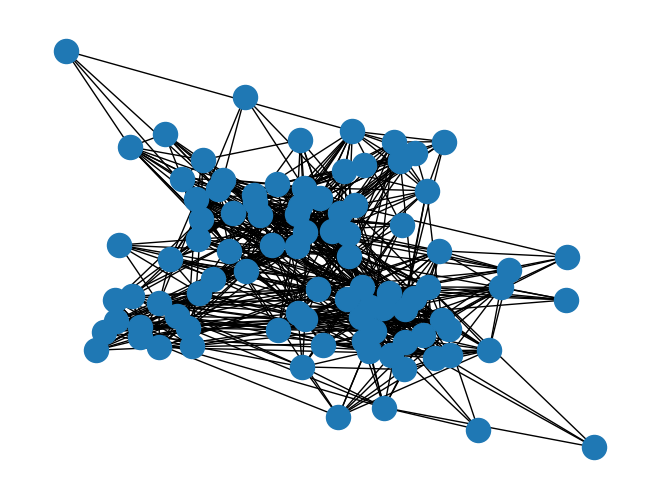

In [8]:
network_name = network_list[4]
G = nx.read_graphml(f'../networks/weighted/G_weighted_{network_name}.graphml')
nx.draw(G)

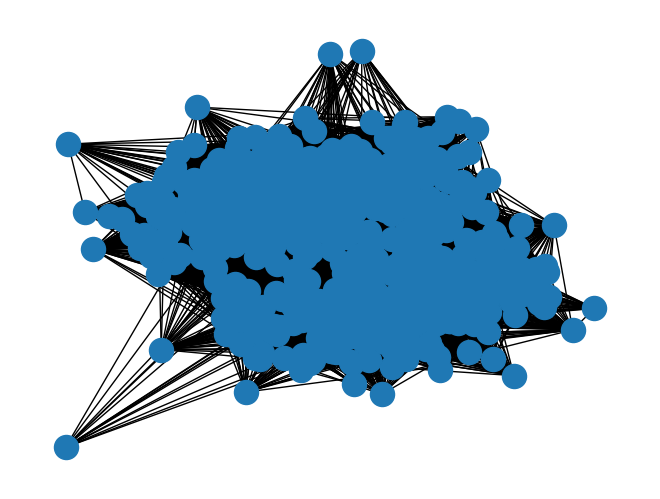

In [7]:
network_name = network_list[3]
G = nx.read_graphml(f'../networks/weighted/G_weighted_{network_name}.graphml')
nx.draw(G)

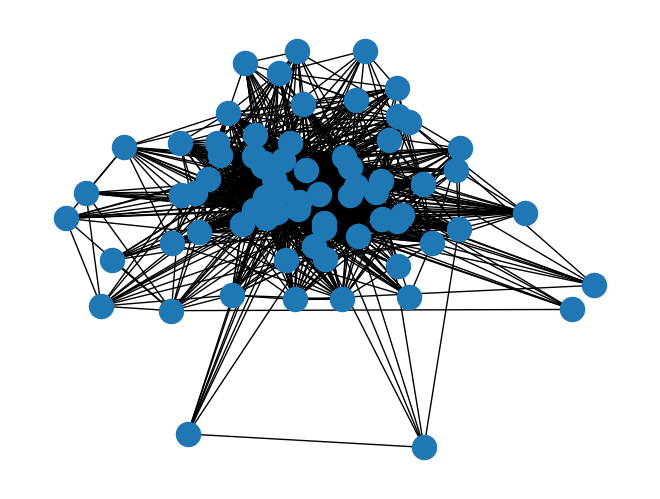

In [6]:
network_name = network_list[2]
G = nx.read_graphml(f'../networks/weighted/G_weighted_{network_name}.graphml')
nx.draw(G)

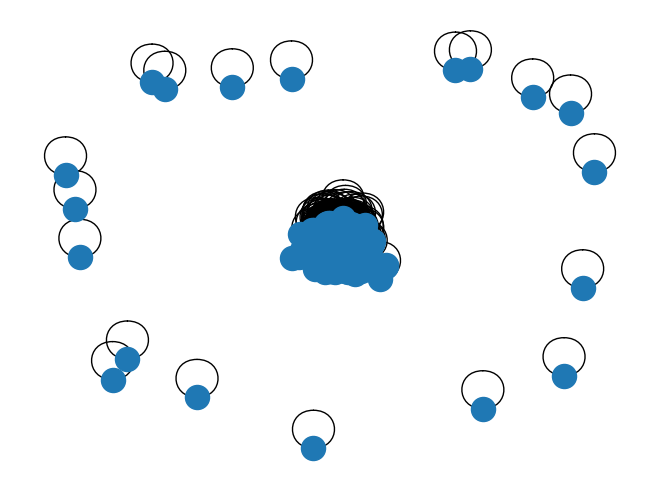

In [5]:
network_name = network_list[1]
G = nx.read_graphml(f'../networks/weighted/G_weighted_{network_name}.graphml')
nx.draw(G)

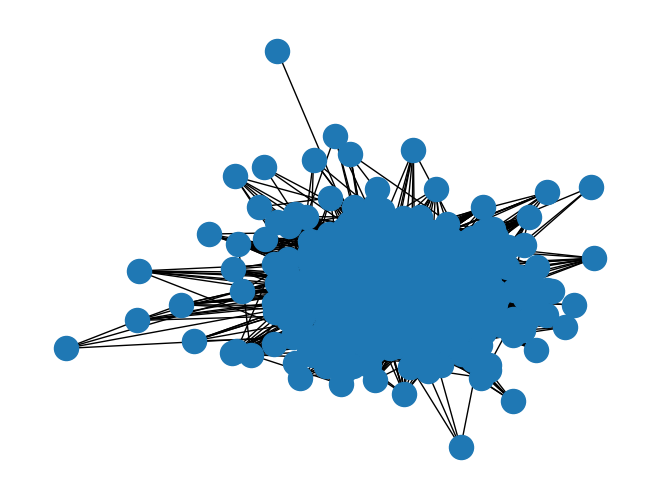

In [4]:
network_name = network_list[0]
G = nx.read_graphml(f'../networks/weighted/G_weighted_{network_name}.graphml')
nx.draw(G)

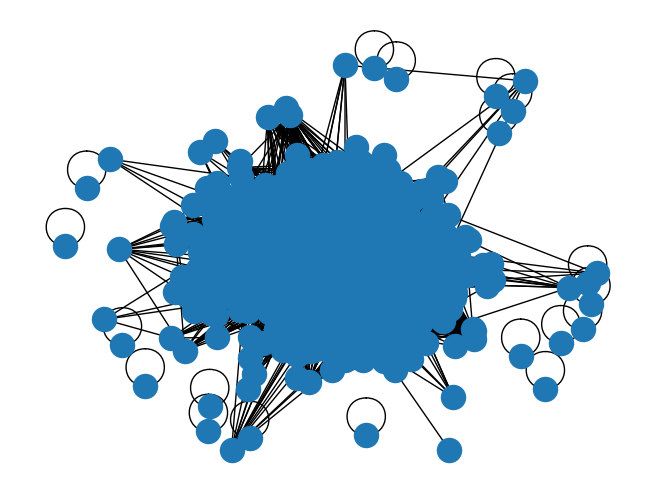

In [3]:
for network_name in network_list:
    G = nx.read_graphml(f'../networks/weighted/G_weighted_{network_name}.graphml')
    nx.draw(G)

In [14]:
network_name = network_list[0]
G = nx.read_graphml(f'../networks/weighted/G_weighted_{network_name}.graphml')
print(nx.average_clustering(G)),print(nx.diameter(G))

0.2817613806101428
4


(None, None)

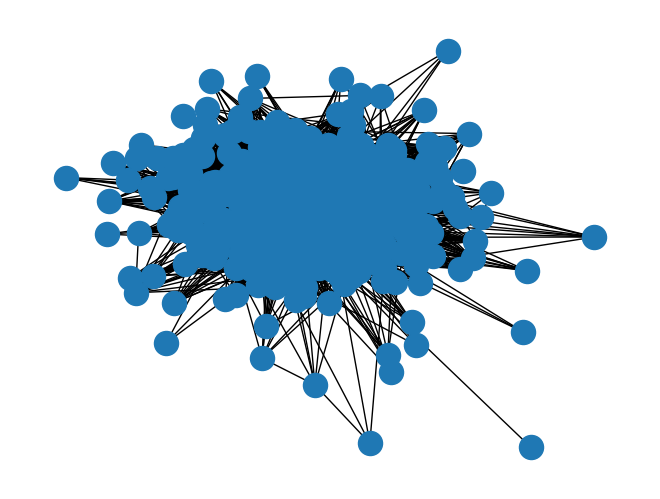

In [15]:
nx.draw(G)

In [16]:
network_name = network_list[1]
G = nx.read_graphml(f'../networks/weighted/G_weighted_{network_name}.graphml')
print(nx.average_clustering(G)),print(nx.diameter(G))

0.3993549664221543


NetworkXError: Found infinite path length because the graph is not connected

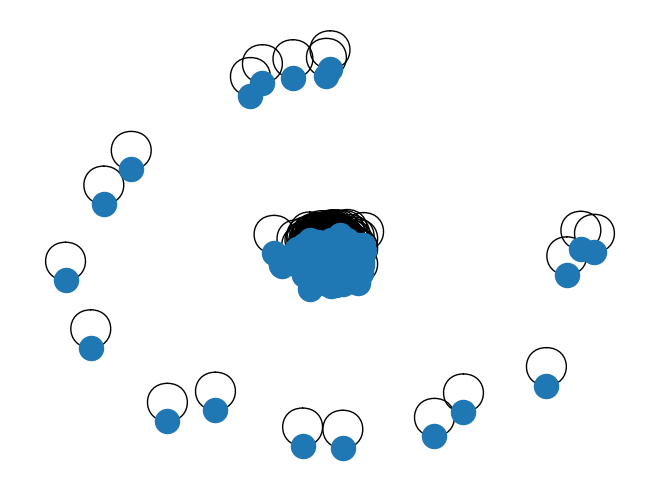

In [17]:
nx.draw(G)

In [26]:
count_wierd = 0 
for i in range(len(nx.to_numpy_array(G))):
    if nx.to_numpy_array(G)[i][i] == 1 and np.sum(nx.to_numpy_array(G)[i]) == 1:
        count_wierd += 1
count_wierd
    

19

In [27]:
len(G.nodes)

1005

In [24]:
G['0.0']

AtlasView({'1.0': {'weight': 1}, '17.0': {'weight': 2}, '316.0': {'weight': 2}, '146.0': {'weight': 2}, '581.0': {'weight': 2}, '268.0': {'weight': 1}, '221.0': {'weight': 2}, '218.0': {'weight': 2}, '18.0': {'weight': 2}, '734.0': {'weight': 2}, '178.0': {'weight': 2}, '380.0': {'weight': 1}, '0.0': {'weight': 1}, '459.0': {'weight': 2}, '215.0': {'weight': 2}, '250.0': {'weight': 2}, '148.0': {'weight': 1}, '73.0': {'weight': 2}, '74.0': {'weight': 2}, '248.0': {'weight': 2}, '498.0': {'weight': 2}, '226.0': {'weight': 1}, '101.0': {'weight': 1}, '377.0': {'weight': 2}, '177.0': {'weight': 2}, '103.0': {'weight': 2}, '560.0': {'weight': 2}, '309.0': {'weight': 2}, '88.0': {'weight': 2}, '5.0': {'weight': 2}, '297.0': {'weight': 1}, '313.0': {'weight': 1}, '223.0': {'weight': 2}, '238.0': {'weight': 2}, '368.0': {'weight': 1}, '266.0': {'weight': 1}, '222.0': {'weight': 2}, '283.0': {'weight': 2}, '6.0': {'weight': 2}, '64.0': {'weight': 1}, '65.0': {'weight': 1}, '166.0': {'weight': 

In [23]:
G.nodes

NodeView(('0.0', '1.0', '2.0', '3.0', '4.0', '5.0', '6.0', '7.0', '8.0', '9.0', '10.0', '11.0', '12.0', '13.0', '14.0', '15.0', '16.0', '17.0', '18.0', '19.0', '20.0', '21.0', '22.0', '23.0', '24.0', '25.0', '26.0', '27.0', '28.0', '29.0', '30.0', '31.0', '32.0', '33.0', '34.0', '35.0', '36.0', '37.0', '38.0', '39.0', '40.0', '41.0', '42.0', '43.0', '44.0', '45.0', '46.0', '47.0', '48.0', '49.0', '50.0', '51.0', '52.0', '53.0', '54.0', '55.0', '56.0', '57.0', '58.0', '59.0', '60.0', '61.0', '62.0', '63.0', '64.0', '65.0', '66.0', '67.0', '68.0', '69.0', '70.0', '71.0', '72.0', '73.0', '74.0', '75.0', '76.0', '77.0', '78.0', '79.0', '80.0', '81.0', '82.0', '83.0', '84.0', '85.0', '86.0', '87.0', '88.0', '89.0', '90.0', '91.0', '92.0', '93.0', '94.0', '95.0', '96.0', '97.0', '98.0', '99.0', '100.0', '101.0', '102.0', '103.0', '104.0', '105.0', '106.0', '107.0', '108.0', '109.0', '110.0', '111.0', '112.0', '113.0', '114.0', '115.0', '116.0', '117.0', '118.0', '119.0', '120.0', '121.0', '1

In [28]:
network_name = network_list[2]
G = nx.read_graphml(f'../networks/weighted/G_weighted_{network_name}.graphml')
print(nx.average_clustering(G)),print(nx.diameter(G))

0.6402796539914468
3


(None, None)

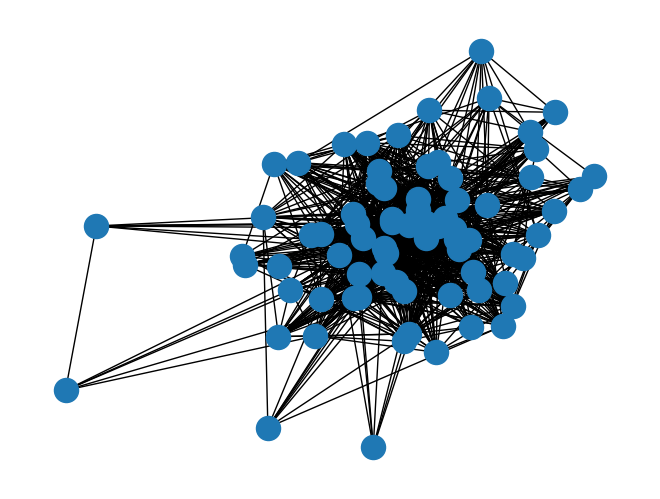

In [29]:
nx.draw(G)

In [11]:
network_name = network_list[3]
G = nx.read_graphml(f'../networks/weighted/G_weighted_{network_name}.graphml')
print(nx.average_clustering(G)),print(nx.diameter(G))

0.30097710541092043
3


(None, None)

In [12]:
network_name = network_list[4]
G = nx.read_graphml(f'../networks/weighted/G_weighted_{network_name}.graphml')
print(nx.average_clustering(G)),print(nx.diameter(G))

0.4260317537699304
3


(None, None)